# Gradient crystal plasticity on a polycrystal SVE

**Keywords**: *crystal plasticity*, *gradient-extended plasticity*, *computational homogenization*,
*mixed/dual formulations*, *subdomains*, *interface elements*, *algebraic variables*, *automatic differentiation*

![](gradient_crystal_plasticity-light.png)
![](gradient_crystal_plasticity-dark.png)

*Figure 1*:
Shear stress $\sigma_{12}$ at the end of the loading in a 50-grain statistical volume
element (SVE) subjected to macroscopic simple shear, for the four combinations of
boundary conditions studied below (semi-dual format, deformation scaled by a factor 10,
colour range clamped at $6000\,\mathrm{MPa}$).

## Introduction

This example reimplements the numerical study in [Carlsson2019](@cite): a polycrystal
modeled with gradient-extended crystal (visco)plasticity, where the slip on each slip
system is penalized by an energy in terms of the *dislocation density tensor*, i.e. the
gradients of the slips. Two variational formats of the same model are implemented:

- the **primal** format, where the displacement $\boldsymbol{u}$ and the slips
  $\gamma_\alpha$ are the global unknowns, and
- the **semi-dual** format, where the slips are replaced by the energetically conjugated
  *microstresses* $\boldsymbol{\xi}_\alpha$ as global unknowns, and the slips become
  local (quadrature point) variables, see [Carlsson2017](@cite).

The model is solved on statistical volume elements (SVEs) with a random polycrystal
structure generated by [Neper](https://neper.info), and we compare the homogenized
response for the different combinations of boundary conditions on the displacements
(Dirichlet/Neumann) and on the microstresses (microhard/microfree) that give upper and
lower bounds of the effective incremental energy, cf. [Carlsson2019](@cite).

The original code for the paper was written in 2016-2017 against a very early version of
Ferrite (then called JuAFEM), and large parts of it, e.g. the mesh reader, the
handling of dofs living only on subdomains, node duplication at grain boundaries and
the constraint handling had to be written by hand. This example shows how the same
analysis can be written with the development version of Ferrite and its surrounding ecosystem.
Run it with the repository's `docs` environment; it uses the new directional-derivative API.
In particular we use

- [`FerriteMeshParser.jl`](https://github.com/Ferrite-FEM/FerriteMeshParser.jl) to read
  the Abaqus `.inp` file written by Neper, including the cell sets for the grains and the
  node/facet sets for the SVE surfaces,
- [`FerriteInterfaceElements.jl`](https://github.com/Ferrite-FEM/FerriteInterfaceElements.jl)
  to duplicate the nodes at the grain boundaries (which the semi-dual format requires,
  since the microstress is discontinuous between grains),
- a `SubDofHandler` for the bulk cells, `AffineConstraint`s to tie the
  displacements of the duplicated nodes, and `Dirichlet` conditions on facet and
  node sets,
- an `AlgebraicVariable` for the macroscopic stress, which acts as Lagrange
  multiplier in the Neumann case where the average strain is prescribed weakly, and
- `ForwardDiff.jl` for all tangents: the element tangent is obtained by differentiating
  the element residual, and for the semi-dual format the local (quadrature point) Newton
  solve is made differentiable by attaching its implicit derivative to the dual numbers.

## Model

### Kinematics and free energy

Small strains are assumed and the strain $\boldsymbol{\epsilon} = (\boldsymbol{u}
\otimes \boldsymbol{\nabla})^\mathrm{sym}$ is split additively into an elastic part and
a plastic part, where the latter originates from slip on the $M$ slip systems of the
crystal:
$$
\boldsymbol{\epsilon}^\mathrm{p} = \sum_{\alpha = 1}^M \gamma_\alpha \boldsymbol{P}_\alpha,
\quad \boldsymbol{P}_\alpha = (\boldsymbol{s}_\alpha \otimes \boldsymbol{m}_\alpha)^\mathrm{sym},
$$
with $\boldsymbol{s}_\alpha$ the slip direction and $\boldsymbol{m}_\alpha$ the slip
plane normal (here: the 12 slip systems of an fcc crystal, randomly rotated in each
grain). The free energy consists of the elastic energy and a gradient (defect) energy in
terms of the edge and screw dislocation densities $\rho^\perp_\alpha = -\boldsymbol{s}_\alpha
\cdot \boldsymbol{\nabla}\gamma_\alpha$ and $\rho^\odot_\alpha = \boldsymbol{k}_\alpha
\cdot \boldsymbol{\nabla}\gamma_\alpha$ ($\boldsymbol{k}_\alpha = \boldsymbol{m}_\alpha
\times \boldsymbol{s}_\alpha$),
$$
\psi = \frac{1}{2} [\boldsymbol{\epsilon} - \boldsymbol{\epsilon}^\mathrm{p}] :
\mathsf{E} : [\boldsymbol{\epsilon} - \boldsymbol{\epsilon}^\mathrm{p}]
+ \frac{1}{2} H l^2 \sum_\alpha \left[ (\rho^\perp_\alpha)^2 + (\rho^\odot_\alpha)^2 \right],
$$
where $l$ is an internal length scale. The stress $\boldsymbol{\sigma} = \mathsf{E} :
[\boldsymbol{\epsilon} - \boldsymbol{\epsilon}^\mathrm{p}]$, the resolved (Schmid)
stress $\tau_\alpha = \boldsymbol{\sigma} : \boldsymbol{P}_\alpha$ and the microstress
$\boldsymbol{\xi}_\alpha = \xi^\perp_\alpha \boldsymbol{s}_\alpha + \xi^\odot_\alpha
\boldsymbol{k}_\alpha$ with $\xi^\perp_\alpha = H l^2\, \boldsymbol{s}_\alpha \cdot
\boldsymbol{\nabla}\gamma_\alpha$ (and similarly for $\xi^\odot_\alpha$) follow from
$\psi$. The slip rate is given by the Norton-type (overstress) law
$$
\dot{\gamma}_\alpha = \frac{1}{t_*} \left[ \frac{|\tau^\mathrm{di}_\alpha|}{C} \right]^m
\mathrm{sgn}(\tau^\mathrm{di}_\alpha),
$$
in terms of the dissipative stress $\tau^\mathrm{di}_\alpha$, which is related to the
energetic quantities through the *microforce balance*
$$
-\tau_\alpha + \tau^\mathrm{di}_\alpha - \boldsymbol{\xi}_\alpha \cdot \boldsymbol{\nabla} = 0
\quad \text{in each grain}.
$$
This balance is a partial differential equation for the slips, which requires boundary
conditions on the grain boundaries: either *microhard*, $\gamma_\alpha = 0$ (no slip
transmitted across the boundary), or *microfree*, $\boldsymbol{\xi}_\alpha \cdot
\boldsymbol{n} = 0$. Following [Carlsson2019](@cite), microhard conditions are used
between the grains, while both types are considered on the outer SVE boundary.

### Primal and semi-dual formats

In the **primal** format the microforce balance is used directly in weak form with the
slips as global fields. With backward Euler in time, the dissipative stress is a function
of the slip increment, $\tau^\mathrm{di}_\alpha = C [t_* |\Delta\gamma_\alpha| /
\Delta t]^{1/m} \mathrm{sgn}(\Delta\gamma_\alpha)$, and the problem reads: find
$\boldsymbol{u}$ and $\gamma_\alpha$ such that
$$
\begin{aligned}
\int_\Omega \boldsymbol{\sigma} : \boldsymbol{\epsilon}[\delta\boldsymbol{u}] \,\mathrm{d}V &= 0
\quad \forall\, \delta\boldsymbol{u}, \\
\int_\Omega \left[ (\tau^\mathrm{di}_\alpha - \tau_\alpha)\, \delta\gamma_\alpha
+ \boldsymbol{\xi}_\alpha \cdot \boldsymbol{\nabla}\delta\gamma_\alpha \right] \mathrm{d}V &= 0
\quad \forall\, \delta\gamma_\alpha,
\end{aligned}
$$
where the microhard condition is a Dirichlet condition on $\gamma_\alpha$ and the
microfree condition is natural. Note that $\tau^\mathrm{di}_\alpha$ has an infinite
slope at $\Delta\gamma_\alpha = 0$ for $m > 1$, which makes Newton's method
fragile; below we use a tiny regularization $|\Delta\gamma| \approx
\sqrt{\Delta\gamma^2 + \delta^2}$ together with a line search.

In the **semi-dual** format a partial Legendre transformation of the gradient energy
replaces the slip gradients by the microstresses as independent fields (living in
$H(\mathrm{div})$ in each grain; here approximated with $H^1$ Lagrange elements per
grain as in the paper). The slips then only appear pointwise and the flow rule is solved
locally in each quadrature point. The global problem reads: find $\boldsymbol{u}$ and
$\xi^\perp_\alpha, \xi^\odot_\alpha$ such that
$$
\begin{aligned}
\int_\Omega \boldsymbol{\sigma} : \boldsymbol{\epsilon}[\delta\boldsymbol{u}] \,\mathrm{d}V &= 0
\quad \forall\, \delta\boldsymbol{u}, \\
-\int_\Omega \left[ \frac{\xi^\perp_\alpha}{H l^2}\, \delta\xi^\perp_\alpha
+ \gamma_\alpha\, \boldsymbol{s}_\alpha \cdot \boldsymbol{\nabla}\delta\xi^\perp_\alpha \right] \mathrm{d}V &= 0
\quad \forall\, \delta\xi^\perp_\alpha,
\end{aligned}
$$
and similarly for $\xi^\odot_\alpha$ with $\boldsymbol{k}_\alpha$, where in each
quadrature point $(\gamma_\alpha, \tau^\mathrm{di}_\alpha)$ solve the local problem
$$
-\tau_\alpha + \tau^\mathrm{di}_\alpha - \chi_\alpha = 0, \qquad
\gamma_\alpha - {}^n\gamma_\alpha - \frac{\Delta t}{t_*} \left[\frac{|\tau^\mathrm{di}_\alpha|}{C}\right]^m
\mathrm{sgn}(\tau^\mathrm{di}_\alpha) = 0,
$$
with $\chi_\alpha = \boldsymbol{\xi}_\alpha \cdot \boldsymbol{\nabla} = \boldsymbol{s}_\alpha
\cdot \boldsymbol{\nabla}\xi^\perp_\alpha + \boldsymbol{k}_\alpha \cdot \boldsymbol{\nabla}\xi^\odot_\alpha$.
The boundary conditions are now of the opposite type: microhard is the natural condition
(the microstress is simply independent in each grain), while microfree,
$\boldsymbol{\xi}_\alpha \cdot \boldsymbol{n} = 0$, is a Dirichlet condition on the
microstress. As in the original implementation we impose the stronger condition
$\xi^\perp_\alpha = \xi^\odot_\alpha = 0$ on the outer boundary, which is simpler than
constraining the normal component (which would require coupling the two components at
nodes on edges and corners). The semi-dual local problem is smooth in
$\tau^\mathrm{di}_\alpha$, so no regularization is needed.

### Boundary conditions and bounds

The SVE occupies a cube of side $L_\square = N^{1/3} L$, with $N$ the number of
grains and $L$ the typical grain size, and is loaded in simple shear by prescribing the
macroscopic displacement gradient $\bar{\boldsymbol{H}}(t) = \frac{t}{T}\bar{\Gamma}\,
\boldsymbol{e}_1 \otimes \boldsymbol{e}_2$. The displacement boundary condition is either
Dirichlet, $\boldsymbol{u} = \bar{\boldsymbol{H}} \cdot \boldsymbol{x}$ on the outer
boundary ($u$D), or Neumann ($u$N), where the volume average of the strain is
prescribed weakly,
$$
\int_\Omega \left[ \boldsymbol{\epsilon} - \bar{\boldsymbol{\epsilon}} \right]
\mathrm{d}V = \boldsymbol{0}, \quad \bar{\boldsymbol{\epsilon}} = \bar{\boldsymbol{H}}^\mathrm{sym},
$$
with the constant macroscopic stress $\bar{\boldsymbol{\sigma}}$ as the (symmetric)
Lagrange multiplier. The multiplier is a global unknown without a spatial domain, which is
precisely what an `AlgebraicVariable` is. The weak constraint does not see rigid
body motions, so these are removed by fixing displacement components at three corners of
the cube (the standard 3-2-1 rule); since the constraint only involves the strain, these
point constraints are free of reaction forces and do not affect the homogenized response.
Combined with microhard ($\xi$N) or microfree
($\xi$D) conditions on the outer boundary this gives the four cases $u$D-$\xi$N,
$u$D-$\xi$D, $u$N-$\xi$N and $u$N-$\xi$D. The main result of
[Carlsson2019](@cite) is that the effective incremental energy
$\bar{\pi}$ (the stationary value of the incremental potential, see the paper for its
definition), averaged over many SVE realizations, is bounded from above by the
$u$D-$\xi$N result and, approximately, from below by the $u$N-$\xi$D result:
$$
\bar{\pi}^{u\mathrm{N}\text{-}\xi\mathrm{D}} \lesssim
\left( \bar{\pi}^{u\mathrm{N}\text{-}\xi\mathrm{N}}, \bar{\pi}, \bar{\pi}^{u\mathrm{D}\text{-}\xi\mathrm{D}} \right) \leq
\bar{\pi}^{u\mathrm{D}\text{-}\xi\mathrm{N}}.
$$
The bounds are statistical statements (expected values over realizations) and, since the
four loading cases have different histories, the ordering can be slightly violated for a
single realization at a given time step. Below we only check the ordering for the single
realization considered here. For the 50-grain SVE we obtain $\bar{\pi} = 26.5$,
$19.5$, $26.7$ and $19.0\,\mathrm{MPa}$ at $t = 15\,\mathrm{s}$ for
$u$D-$\xi$N, $u$D-$\xi$D, $u$N-$\xi$N and $u$N-$\xi$D, close to Figure
6 in the paper ($29.0$, $21.4$, $29.0$ and $20.5\,\mathrm{MPa}$) and with the
same marginal violation $u$N-$\xi$N $>$ $u$D-$\xi$N that is discussed there.

## Implementation

The default settings of this example use a coarse 10-grain SVE and large time steps such
that it runs in a few minutes; the figures on this page are from the 50-grain SVE with
the time stepping of the paper, obtained by setting the environment variable
`FERRITE_GCP_FULL=true` before running the script.

In [1]:
using Ferrite, FerriteMeshParser, FerriteInterfaceElements, VTKHDF
using Tensors, ForwardDiff, LinearAlgebra, SparseArrays, Random, Printf, Downloads
import LinearSolve
using Ferrite: OrderedSet
import Plots

const FULL = get(ENV, "FERRITE_GCP_FULL", "false") == "true"

false

### Mesh

The SVE is generated with Neper (`neper -T -n N -id 1 -morpho "diameq:dirac(1),1-sphericity:lognormal(0.145,0.03)"`,
followed by `neper -M N.tess -dim 3 -order 1 -format inp`), see the appendix of the
paper. The resulting Abaqus file contains the tetrahedra, a cell set `polyX` for each
grain and node sets for the six faces of the unit cube, which FerriteMeshParser reads
directly (the face node sets are turned into facet sets). We scale the unit cube to the
side length $L_\square = N^{1/3}$ with $L = 1\,\mathrm{\mu m}$ as the length unit.

In the semi-dual format the microstresses are discontinuous across grain boundaries, so
the grains must not share nodes. FerriteInterfaceElements can insert interface cells
between subdomains, which duplicates the nodes on the shared facets; the displacement
is made continuous again by tying the duplicates with affine constraints below. The grid
then contains two kinds of cells: the tetrahedra of the grains, collected in the cell set
`"bulk"`, and the zero-thickness interface cells (one per grain boundary facet). Only the
tetrahedra carry dofs and are integrated over; the interface cells are only used to find
the duplicated nodes here, but could carry a grain boundary energy or a cohesive law.

In [2]:
function load_sve(inpfile)
    grid = get_ferrite_grid(inpfile; generate_facetsets = false)
    dim = Ferrite.getspatialdim(grid)
    grains = sort!(filter(startswith("poly"), collect(keys(Ferrite.getcellsets(grid)))); by = n -> parse(Int, chopprefix(n, "poly")))
    L = length(grains)^(1 / dim)
    transform_coordinates!(grid, x -> L * x)
    tol = 1.0e-8 * L
    faces = ("x0", "x1", "y0", "y1", "z0", "z1")
    for name in faces
        addfacetset!(grid, name, FerriteMeshParser.create_facetset(grid, getnodeset(grid, name)))
    end
    addfacetset!(grid, "boundary", union((getfacetset(grid, n) for n in faces)...))
    grid = insert_interfaces(grid, grains)

    # Corner sets used below to remove rigid-body motion.
    for (name, corner) in (("origin", zero(Vec{dim})), ("corner_x", L * basevec(Vec{dim}, 1)), ("corner_y", L * basevec(Vec{dim}, 2)))
        addnodeset!(grid, name, x -> norm(x - corner) < tol)
    end
    addnodeset!(grid, "grain_boundary", OrderedSet{Int}(n for c in getcells(grid) if c isa InterfaceCell for n in c.nodes))
    addcellset!(grid, "bulk", OrderedSet{Int}(i for (i, c) in enumerate(getcells(grid)) if c isa Tetrahedron))
    grain_of_cell = zeros(Int, getncells(grid))
    for (g, name) in enumerate(grains), c in getcellset(grid, name)
        grain_of_cell[c] = g
    end
    return grid, grain_of_cell
end

load_sve (generic function with 1 method)

### Material

The material parameters are those of the paper in the units MPa, μm and s, with the
grain size $L = 1\,\mathrm{\mu m}$. The gradient hardening parameter and the length
scale only appear in the combination $H l^2$; Table 1 of the paper lists $H = 2 \cdot
10^7\,\mathrm{MPa}$ and $l = 10^{-9}\,\mathrm{m}$ with $L = 10^3 l$, but the driver
script used for the computations of the paper used $l = 0.1 L$ and $H = 0.1 E$, i.e. a
ten times larger $H l^2 = 200\,\mathrm{MPa\,\mu m^2}$, which is what reproduces the
energies of Figure 6 in the paper. Each grain gets the 12 fcc slip systems rotated by a
random rotation.
The fcc slip systems and the SVE mesh are three-dimensional; the material and
state types below infer their tensor dimensions from these inputs.

In [3]:
struct CrystalMaterial{dim, T, N4, N2}
    E::SymmetricTensor{4, dim, T, N4}
    s::Vector{Vec{dim, T}}                     # slip directions
    k::Vector{Vec{dim, T}}                     # m × s
    P::Vector{SymmetricTensor{2, dim, T, N2}}   # (s ⊗ m)ˢʸᵐ
    Hl2::T                                   # gradient hardening H l²
    C::T                                     # reference stress
    tstar::T                                 # reference time
    m::T                                     # Norton exponent
end
nslips(mat::CrystalMaterial) = length(mat.s)

function fcc_slip_systems()
    planes = [Vec((1.0, 1.0, -1.0)), Vec((1.0, -1.0, -1.0)), Vec((1.0, -1.0, 1.0)), Vec((1.0, 1.0, 1.0))] ./ √3
    dirs = [
        (0.0, 1.0, 1.0), (1.0, 0.0, 1.0), (1.0, -1.0, 0.0), (0.0, 1.0, -1.0), (1.0, 0.0, 1.0), (1.0, 1.0, 0.0),
        (0.0, 1.0, 1.0), (1.0, 0.0, -1.0), (1.0, 1.0, 0.0), (0.0, 1.0, -1.0), (1.0, 0.0, -1.0), (1.0, -1.0, 0.0),
    ]
    s = [Vec(d) / √2 for d in dirs]
    m = repeat(planes; inner = 3) # three slip directions per plane
    return s, m
end

function CrystalMaterial(; E, ν, H, l, C, tstar, m, rotation)
    dim = size(rotation, 1)
    λ = E * ν / ((1 + ν) * (1 - 2ν))
    μ = E / (2(1 + ν))
    δ(i, j) = i == j ? 1.0 : 0.0
    Eᵉ = SymmetricTensor{4, dim}((i, j, k, l) -> λ * δ(i, j) * δ(k, l) + μ * (δ(i, k) * δ(j, l) + δ(i, l) * δ(j, k)))
    s0, m0 = fcc_slip_systems()
    s = [rotation ⋅ sα for sα in s0]
    n = [rotation ⋅ mα for mα in m0]
    k = [nα × sα for (sα, nα) in zip(s, n)]
    P = [symmetric(sα ⊗ nα) for (sα, nα) in zip(s, n)]
    return CrystalMaterial(Eᵉ, s, k, P, H * l^2, C, tstar, m)
end

function random_rotation(rng)
    z = 2rand(rng) - 1
    ϕ = 2π * rand(rng)
    u = Vec((sqrt(1 - z^2) * cos(ϕ), sqrt(1 - z^2) * sin(ϕ), z)) # uniform on the sphere
    θ = 2π * rand(rng)
    # The skew tensor represents the cross product: W ⋅ v = u × v.
    W = Tensor{2, length(u)}(
        [
            0.0   -u[3]  u[2]
            u[3]   0.0  -u[1]
            -u[2]  u[1]  0.0
        ]
    )
    return one(W) + sin(θ) * W + (1 - cos(θ)) * (W ⋅ W) # Rodrigues' formula
end

function paper_materials(ngrains)
    rng = Xoshiro(1234)
    return [
        CrystalMaterial(; E = 200.0e3, ν = 0.3, H = 2.0e4, l = 0.1, C = 1.0e3, tstar = 1.0e3, m = 2.0, rotation = random_rotation(rng))
            for _ in 1:ngrains
    ]
end

paper_materials (generic function with 1 method)

### Quadrature point state

The state in each quadrature point holds the slips and dissipative stresses of the last
converged step, the stress and strain for postprocessing, and the free energy and
incremental potential $\pi$ (integrated to $\bar{\pi}$) of the current step. For the
semi-dual format it also caches the solution of the local problem and its derivative,
such that the local problem is solved only once per quadrature point and assembly, even
though the element residual is evaluated several times when computing the element
tangent with ForwardDiff.

In [4]:
mutable struct QPState{S}
    γ::Vector{Float64}
    τdi::Vector{Float64}
    σ::S
    ε::S
    φ::Float64
    π::Float64
    Y::Vector{Float64}   # cache: outer variables (ε, χ⊥, χ⊙) of the local problem,
    X::Vector{Float64}   #        its solution (γ, τᵈⁱ)
    A::Matrix{Float64}   #        and the derivative dX/dY
    Avalid::Bool
end

The vectors $X$ and $Y$ of the local problem are laid out as described by

In [5]:
struct LocalLayout
    ε::UnitRange{Int}    # Y: strain in Voigt notation
    χp::UnitRange{Int}   # Y: χ⊥ₐ
    χo::UnitRange{Int}   # Y: χ⊙ₐ
    γ::UnitRange{Int}    # X: slips
    τdi::UnitRange{Int}  # X: dissipative stresses
end
function LocalLayout(mat::CrystalMaterial{dim}) where {dim}
    M = nslips(mat)
    nε = Tensors.n_components(SymmetricTensor{2, dim})
    return LocalLayout(1:nε, nε .+ (1:M), (nε + M) .+ (1:M), 1:M, M .+ (1:M))
end
nX(ll::LocalLayout) = last(ll.τdi)
nY(ll::LocalLayout) = last(ll.χo)

function QPState(mat)
    M = nslips(mat)
    ll = LocalLayout(mat)
    z = zero(eltype(mat.P))
    return QPState(
        zeros(M), zeros(M), z, z, 0.0, 0.0,
        fill(NaN, nY(ll)), zeros(nX(ll)), zeros(nX(ll), nY(ll)), false
    )
end
function update_state!(new::QPState, old::QPState)
    new.γ .= old.γ
    new.τdi .= old.τdi
    new.σ = old.σ
    new.ε = old.ε
    new.φ = old.φ
    new.π = old.π
    return new
end

update_state! (generic function with 1 method)

### Local problem of the semi-dual format

The unknowns of the local problem are $X = (\gamma_\alpha, \tau^\mathrm{di}_\alpha)$
and the "outer" variables provided by the element are $Y = (\boldsymbol{\epsilon},
\chi^\perp_\alpha, \chi^\odot_\alpha)$. The residual is written generically such that
both its Jacobians (with respect to $X$ for the local Newton iterations and with
respect to $Y$ for the consistent tangent) can be computed with ForwardDiff.

In [6]:
function local_residual!(R, X, Y, γn, mat::CrystalMaterial{dim}, Δt) where {dim}
    ll = LocalLayout(mat)
    ε = fromvoigt(SymmetricTensor{2, dim}, view(Y, ll.ε))
    γ = view(X, ll.γ)
    τdi = view(X, ll.τdi)
    εp = zero(promote_type(eltype(X), eltype(Y))) * mat.P[1]
    for α in 1:nslips(mat)
        εp += γ[α] * mat.P[α]
    end
    σ = mat.E ⊡ (ε - εp)
    for α in 1:nslips(mat)
        τ = σ ⊡ mat.P[α]
        χ = Y[ll.χp[α]] + Y[ll.χo[α]]
        R[ll.γ[α]] = (-τ + τdi[α] - χ) / mat.C
        R[ll.τdi[α]] = (γ[α] - γn[α]) - Δt / mat.tstar * (abs(τdi[α]) / mat.C)^mat.m * sign(τdi[α])
    end
    return R
end

function local_newton!(X, Y, γn, mat, Δt; tol = 1.0e-12, maxiter = 50)
    R = similar(X)
    J = Matrix{eltype(X)}(undef, length(X), length(X))
    f!(R, X) = local_residual!(R, X, Y, γn, mat, Δt)
    cfg = ForwardDiff.JacobianConfig(f!, R, X)
    for _ in 1:maxiter
        f!(R, X)
        norm(R) < tol && return X
        ForwardDiff.jacobian!(J, f!, R, X, cfg)
        ldiv!(lu!(J), R)
        X .-= R
    end
    return error("local problem did not converge")
end

local_newton! (generic function with 1 method)

The element residual below calls `local_solve` with a vector of ForwardDiff dual
numbers when the element tangent is computed. Instead of differentiating through the
Newton iterations we solve the local problem for the values, compute the derivative
$\mathrm{d}X/\mathrm{d}Y = -[\partial R/\partial X]^{-1} \partial R/\partial Y$ from the
implicit function theorem, and attach it to the dual numbers.
If $Y = Y_v + \mathrm{d}Y$ is a vector of dual numbers, `Y .- Yv` has zero
value and retains only their derivative parts. Thus `X + A * (Y - Yv)` has the
converged value $X$ and derivative $A\,\mathrm{d}Y$. This applies the chain
rule exactly for first derivatives; it does not take another Newton step or
approximate the value of the local solution.

In [7]:
value(x::Real) = ForwardDiff.value(x)
value(x::SymmetricTensor{2, dim}) where {dim} = SymmetricTensor{2, dim}(map(ForwardDiff.value, Tensors.get_data(x)))

function local_solve(Y::AbstractVector{T}, st::QPState, γn, mat, Δt) where {T}
    ll = LocalLayout(mat)
    Yv = ForwardDiff.value.(Y)
    if Yv != st.Y
        st.X[ll.γ] .= st.γ # initial guess
        st.X[ll.τdi] .= st.τdi
        local_newton!(st.X, Yv, γn, mat, Δt)
        copyto!(st.Y, Yv)
        st.Avalid = false
    end
    T === Float64 && return copy(st.X)
    if !st.Avalid
        JX = ForwardDiff.jacobian((R, X) -> local_residual!(R, X, Yv, γn, mat, Δt), zeros(nX(ll)), st.X)
        JY = ForwardDiff.jacobian((R, Y) -> local_residual!(R, st.X, Y, γn, mat, Δt), zeros(nX(ll)), Yv)
        st.A .= -(JX \ JY)
        st.Avalid = true
    end
    dY = Y .- Yv
    X = st.A * dY
    X .+= st.X
    return X
end

local_solve (generic function with 1 method)

### Dissipation of the primal format

With backward Euler, the dissipative stress of the primal format is a function of the
slip increment. The regularized absolute value
$|\Delta\gamma|_\delta = \sqrt{\Delta\gamma^2 + \delta^2}$ removes the infinite slope
at $\Delta\gamma = 0$, and the corresponding
(regularized) dissipation $\Delta t\, \phi$ enters the incremental potential.

In [8]:
function dissipative_stress(Δγ, mat::CrystalMaterial, Δt, δ)
    A = mat.C * (mat.tstar / Δt)^(1 / mat.m)
    return A * Δγ * (Δγ^2 + δ^2)^((1 / mat.m - 1) / 2)
end
function dissipation(Δγ, mat::CrystalMaterial, Δt, δ)
    A = mat.C * (mat.tstar / Δt)^(1 / mat.m)
    p = (mat.m + 1) / mat.m
    return A * mat.m / (mat.m + 1) * ((Δγ^2 + δ^2)^(p / 2) - δ^p)
end

dissipation (generic function with 1 method)

### Element residuals

The local dof layout of an element is described by the ranges of the displacement
field, the $M$ gradient fields ($\xi^\perp_\alpha$ and $\xi^\odot_\alpha$ in the
semi-dual format, $\gamma_\alpha$ in the primal format), and, in the Neumann case, the
dofs of the multiplier $\bar{\boldsymbol{\sigma}}$ that are appended to the element dofs.

In [9]:
struct Layout
    u::UnitRange{Int}
    ξp::Vector{UnitRange{Int}}
    ξo::Vector{UnitRange{Int}}
    σ̄::UnitRange{Int}
end

struct Problem{CV, SV, F}
    format::Symbol          # :dual or :primal
    cv::CV                 # MultiFieldCellValues for displacement and scalar fields
    layout::Layout
    σ̄vals::SV               # AlgebraicValues of σ̄ (Neumann) or nothing (Dirichlet)
    Hbar::F                 # t -> macroscopic displacement gradient
    Δt::Float64
    δreg::Float64           # regularization of |Δγ| (primal format)
end

Both formats share the displacement part of the residual and the Neumann terms; the
dispatch on the format is made inside the loop over quadrature points. Only the residual
is coded, the element tangent is computed with ForwardDiff in the assembly. The state
variables are also updated here (with the values of the dual numbers) such that the
states are consistent with the last evaluated residual.

In [10]:
function element_residual!(re, ae, ae_n, states, states_n, mat::CrystalMaterial{dim}, prob::Problem, t) where {dim}
    (; cv, layout, Δt, δreg) = prob
    M = nslips(mat)
    ll = LocalLayout(mat)
    T = eltype(ae)
    fill!(re, zero(T))
    u = @view ae[layout.u]
    ru = @view re[layout.u]
    nu = getnbasefunctions(cv.u)
    ns = getnbasefunctions(cv.s)
    Y = Vector{T}(undef, nY(ll))
    ξp = Vector{T}(undef, M)
    ξo = Vector{T}(undef, M)
    γ = Vector{T}(undef, M)
    ∇γ = Vector{Vec{dim, T}}(undef, M)
    if prob.σ̄vals !== nothing
        σ̄ = algebraic_value(prob.σ̄vals, ae, layout.σ̄)
        ε̄ = symmetric(prob.Hbar(t))
    end
    for qp in 1:getnquadpoints(cv)
        dΩ = getdetJdV(cv, qp)
        ∇u = function_gradient(cv.u, qp, u)
        ε = symmetric(∇u)
        st, stn = states[qp], states_n[qp]
        εp = zero(T) * mat.P[1]
        if prob.format === :dual
            tovoigt!(view(Y, ll.ε), ε)
            for α in 1:M
                ap = view(ae, layout.ξp[α])
                ao = view(ae, layout.ξo[α])
                ξp[α] = function_value(cv.s, qp, ap)
                ξo[α] = function_value(cv.s, qp, ao)
                Y[ll.χp[α]] = function_directional_derivative(cv.s, qp, ap, mat.s[α])
                Y[ll.χo[α]] = function_directional_derivative(cv.s, qp, ao, mat.k[α])
            end
            X = local_solve(Y, st, stn.γ, mat, Δt)
            γ = view(X, ll.γ)
            τdi = view(X, ll.τdi)
            for α in 1:M
                εp += γ[α] * mat.P[α]
            end
            σ = mat.E ⊡ (ε - εp)
            for α in 1:M
                rp = view(re, layout.ξp[α])
                ro = view(re, layout.ξo[α])
                sα, kα = mat.s[α], mat.k[α]
                ξpα, ξoα, γα = ξp[α], ξo[α], γ[α]
                for i in 1:ns
                    δξ = shape_value(cv.s, qp, i)
                    ∇δξ = shape_gradient(cv.s, qp, i)
                    rp[i] -= (ξpα / mat.Hl2 * δξ + (∇δξ ⋅ sα) * γα) * dΩ
                    ro[i] -= (ξoα / mat.Hl2 * δξ + (∇δξ ⋅ kα) * γα) * dΩ
                end
            end
            # Semi-dual free energy φ = ψᵉ - ψᵍ* and incremental potential
            # These are only used for postprocessing, so discard derivatives first.
            εe = value(ε - εp)
            φ = 1 / 2 * εe ⊡ mat.E ⊡ εe - sum(value(ξp[α])^2 + value(ξo[α])^2 for α in 1:M) / (2mat.Hl2)
            st.γ .= value.(γ)
            st.τdi .= value.(τdi)
            π = φ - stn.φ
            for α in 1:M
                χ = value(Y[ll.χp[α]]) + value(Y[ll.χo[α]])
                γα, τdiα = st.γ[α], st.τdi[α]
                π += τdiα * (γα - stn.γ[α]) - χ * γα - Δt / mat.tstar * mat.C / (mat.m + 1) * (abs(τdiα) / mat.C)^(mat.m + 1)
            end
        else # primal
            for α in 1:M
                aγ = view(ae, layout.ξp[α])
                γ[α] = function_value(cv.s, qp, aγ)
                ∇γ[α] = function_gradient(cv.s, qp, aγ)
                εp += γ[α] * mat.P[α]
            end
            σ = mat.E ⊡ (ε - εp)
            εe = value(ε - εp)
            ψe = 1 / 2 * εe ⊡ mat.E ⊡ εe
            ψg = 0.0 # gradient energy, summed over the slip systems
            Δtϕ = 0.0 # dissipation
            for α in 1:M
                γdofs = layout.ξp[α]
                rγ = view(re, γdofs)
                τ = σ ⊡ mat.P[α]
                Δγ = γ[α] - function_value(cv.s, qp, view(ae_n, γdofs))
                τdi = dissipative_stress(Δγ, mat, Δt, δreg)
                gp = ∇γ[α] ⋅ mat.s[α]
                go = ∇γ[α] ⋅ mat.k[α]
                ξ = mat.Hl2 * (gp * mat.s[α] + go * mat.k[α])
                for i in 1:ns
                    δγ = shape_value(cv.s, qp, i)
                    ∇δγ = shape_gradient(cv.s, qp, i)
                    rγ[i] += (δγ * (τdi - τ) + ∇δγ ⋅ ξ) * dΩ
                end
                ψg += mat.Hl2 / 2 * (value(gp)^2 + value(go)^2)
                Δtϕ += dissipation(value(Δγ), mat, Δt, δreg)
                st.γ[α] = value(γ[α])
                st.τdi[α] = value(τdi)
            end
            # Same reference as in the semi-dual format: φ = ψᵉ - ψᵍ* = ψᵉ - ψᵍ at the solution,
            # and the term -χ ⋆ γ of the incremental potential equals ξ ⋆ ∇γ = 2ψᵍ after
            # integration by parts
            φ = ψe - ψg
            π = ψe + ψg - stn.φ + Δtϕ
        end
        for i in 1:nu
            ru[i] += (shape_symmetric_gradient(cv.u, qp, i) ⊡ σ) * dΩ
        end
        if prob.σ̄vals !== nothing # Neumann: multiplier terms
            for i in 1:nu
                ru[i] -= (σ̄ ⊡ shape_symmetric_gradient(cv.u, qp, i)) * dΩ
            end
            for (k, I) in pairs(layout.σ̄)
                re[I] -= (algebraic_basis_value(prob.σ̄vals, k) ⊡ (ε - ε̄)) * dΩ
            end
        end
        st.σ = value(σ)
        st.ε = value(ε)
        st.φ = φ
        st.π = π
    end
    return re
end

element_residual! (generic function with 1 method)

### Dofs, constraints and assembly

The fields live on the tetrahedra, so they are added to a `SubDofHandler` for the
`"bulk"` cell set. Since the nodes on the grain boundaries are duplicated, all fields
are automatically discontinuous between grains. For the displacements, which should be
continuous, the duplicates are tied together with `AffineConstraint`s. To find the dofs
of the two copies of a node, the interface cells get the displacement field too, on a
second `SubDofHandler` with an `InterfaceCellInterpolation`: vertex dofs are shared by
node id, so this adds no dofs, and the cell dofs of an interface cell are exactly the
displacement dofs of its `here` nodes followed by those of its `there` nodes. One tie
per node pair, with the higher node id constrained to the lower. A node at a triple
junction is duplicated twice, so the ties are nested ($u_{A''} = u_{A'}$ with
$u_{A'} = u_A$); the constraint handler resolves such chains in `close!`. Constraints
added later override earlier ones, so the Dirichlet conditions are added after the ties.

In [11]:
function setup(grid, materials, format, ubc, ξbc, Hbar, Δt; δreg = 1.0e-6)
    M = nslips(materials[1])
    dim = Ferrite.getspatialdim(grid)
    ip = Lagrange{RefTetrahedron, 1}()
    dh = DofHandler(grid)
    sdh = SubDofHandler(dh, getcellset(grid, "bulk"))
    add!(sdh, :u, ip^dim)
    if format === :dual
        names_p = [Symbol("ξ⊥", α) for α in 1:M]
        names_o = [Symbol("ξ⊙", α) for α in 1:M]
    else
        names_p = [Symbol("γ", α) for α in 1:M]
        names_o = Symbol[]
    end
    foreach(n -> add!(sdh, n, ip), names_p)
    foreach(n -> add!(sdh, n, ip), names_o)
    sdh_interface = SubDofHandler(dh, getcellset(grid, "interfaces"))
    add!(sdh_interface, :u, InterfaceCellInterpolation(Lagrange{RefTriangle, 1}())^dim)
    σ̄var = AlgebraicVariable{SymmetricTensor{2, dim}}()
    σ̄vals = ubc === :neumann ? AlgebraicValues(σ̄var) : nothing
    ubc === :neumann && add!(dh, :σ̄, σ̄var)
    close!(dh)
    n = ndofs_per_cell(sdh)
    nσ̄ = ubc === :neumann ? getnbasefunctions(σ̄vals) : 0
    layout = Layout(dof_range(sdh, :u), [dof_range(sdh, n) for n in names_p], [dof_range(sdh, n) for n in names_o], (n + 1):(n + nσ̄))

    ch = ConstraintHandler(dh)
    for cell in CellIterator(sdh_interface)
        c = getcells(grid, cellid(cell))
        udofs = reshape(celldofs(cell), dim, :) # one column per vertex: the `here` vertices, then the `there` vertices
        nv = length(c.here.nodes)
        for (v, (h, t)) in enumerate(zip(c.here.nodes, c.there.nodes))
            slaves, masters = h > t ? (udofs[:, v], udofs[:, nv + v]) : (udofs[:, nv + v], udofs[:, v])
            for (slave, master) in zip(slaves, masters)
                add!(ch, AffineConstraint(slave, [master => 1.0], 0.0))
            end
        end
    end
    if ubc === :dirichlet
        add!(ch, Dirichlet(:u, getfacetset(grid, "boundary"), (x, t) -> Hbar(t) ⋅ x))
    else # remove the rigid body motions: fix the origin, u₂ and u₃ on the x-axis, u₃ on the y-axis
        add!(ch, Dirichlet(:u, getnodeset(grid, "origin"), Returns(zero(Vec{dim}))))
        add!(ch, Dirichlet(:u, getnodeset(grid, "corner_x"), Returns(zeros(dim - 1)), collect(2:dim)))
        add!(ch, Dirichlet(:u, getnodeset(grid, "corner_y"), Returns(zeros(dim - 2)), collect(3:dim)))
    end
    if format === :dual && ξbc === :microfree
        for name in vcat(names_p, names_o)
            add!(ch, Dirichlet(name, getfacetset(grid, "boundary"), Returns(0.0)))
        end
    elseif format === :primal
        for name in names_p
            isempty(getnodeset(grid, "grain_boundary")) || add!(ch, Dirichlet(name, getnodeset(grid, "grain_boundary"), Returns(0.0)))
            ξbc === :microhard && add!(ch, Dirichlet(name, getfacetset(grid, "boundary"), Returns(0.0)))
        end
    end
    close!(ch)

    # Four points integrate the quadratic ξ δξ term exactly; the archived paper code
    # used one point, which underintegrates this term.
    # Possible optimization for the dual format on affine linear tetrahedra: ε and
    # the directional gradients of ξ are constant, so matching previous material
    # states permit reusing the local material solution and tangent across points
    # while still integrating ξ δξ with four points. Keep the per-point evaluation
    # here to support quadratic elements and differing quadrature-point histories.
    qr = QuadratureRule{RefTetrahedron}(2)
    cv = MultiFieldCellValues(qr, (u = ip^dim, s = ip))
    prob = Problem(format, cv, layout, σ̄vals, Hbar, Δt, δreg)
    if ubc === :neumann
        coupling = CellCoupling(getcellset(grid, "bulk"); algebraic_coupling = ((:u, :σ̄),))
        K = allocate_matrix(dh, ch; algebraic_couplings = coupling)
    else
        K = allocate_matrix(dh, ch)
    end
    states = [[QPState(materials[1]) for _ in 1:getnquadpoints(cv)] for _ in 1:getncells(grid)]
    states_n = deepcopy(states)
    return dh, sdh, ch, K, prob, states, states_n
end

setup (generic function with 1 method)

The assembly computes the element tangent with `ForwardDiff.jacobian!`, which also
returns the residual. In the Neumann case the dof vector of each element is augmented
with the (global) dofs of the multiplier.

In [12]:
function assemble_system!(K, r, a, a_n, dh, sdh, prob, states, states_n, materials, grain_of_cell, t)
    assembler = start_assemble(K, r)
    n = ndofs_per_cell(sdh)
    nσ̄ = length(prob.layout.σ̄)
    dofs = Vector{Int}(undef, n + nσ̄)
    nσ̄ > 0 && (dofs[prob.layout.σ̄] .= algebraic_dofs(dh, :σ̄))
    re = zeros(n + nσ̄)
    Ke = zeros(n + nσ̄, n + nσ̄)
    ae = zeros(n + nσ̄)
    ae_n = zeros(n + nσ̄)
    cellid = Ref(0)
    f! = (re, ae) -> element_residual!(re, ae, ae_n, states[cellid[]], states_n[cellid[]], materials[grain_of_cell[cellid[]]], prob, t)
    cfg = ForwardDiff.JacobianConfig(f!, re, ae)
    for cell in CellIterator(sdh)
        cellid[] = Ferrite.cellid(cell)
        copyto!(dofs, celldofs(cell))
        ae .= view(a, dofs)
        ae_n .= view(a_n, dofs)
        reinit!(prob.cv, cell)
        ForwardDiff.jacobian!(Ke, f!, re, ae, cfg)
        assemble!(assembler, dofs, Ke, re)
    end
    return
end

assemble_system! (generic function with 1 method)

### Time stepping and Newton iterations

The solution is extrapolated from the previous step as predictor (this keeps the primal
format away from the singular point $\Delta\gamma_\alpha = 0$ of the dissipative
stress). The Newton iterations use a backtracking line search based on the natural
monotonicity test of Deuflhard: a trial point is accepted if the simplified Newton
correction (with the already factorized tangent) is shorter than the current one. Unlike
a test on the residual norm this is insensitive to the very different scales of the
residual blocks (forces, microstress equations and the multiplier equations).
We use the caching interface of LinearSolve to reuse the symbolic factorization
between Newton iterations, since the sparsity pattern is fixed. Assigning `A` marks
the numeric factorization for updating; assigning only `b` in the line search reuses
the current factors. The `linsolve` keyword can be used to compare sparse solvers.
UMFPACK is the default; pass `linsolve = LinearSolve.KLUFactorization()` to try KLU.

After each step the homogenized stress $\bar{\boldsymbol{\sigma}} = \langle
\boldsymbol{\sigma} \rangle$, strain and incremental energy $\bar{\pi} = \langle \pi
\rangle$ are computed, and the stress, the sum of absolute slips and the displacements are
appended to a temporal `VTKHDFGridFile`: the grid is stored once and every load
step goes into the same file. The interface cells are exported as zero-thickness wedges
(they have no state, so their cell data is `NaN`). The stress is projected to the nodes
with an `L2Projector`, grain by grain since the nodes are duplicated, so it
stays discontinuous across grain boundaries. For the figures the outer surface of the
SVE is written to a second file as a grid of triangles: since the grains do not share
nodes, every grain boundary facet is an "exterior" facet of the volume mesh and would
otherwise be rendered too.

In [13]:
function solve_sve(
        grid, grain_of_cell, materials; format, ubc, ξbc, Γ = 0.1, T = 15.0, nsteps = 30,
        vtkfile = nothing, verbose = true, linsolve = LinearSolve.UMFPACKFactorization(),
    )
    Δt = T / nsteps
    dim = Ferrite.getspatialdim(grid)
    Hshear = basevec(Vec{dim}, 1) ⊗ basevec(Vec{dim}, 2)
    Hbar(t) = (t / T * Γ) * Hshear
    dh, sdh, ch, K, prob, states, states_n = setup(grid, materials, format, ubc, ξbc, Hbar, Δt)
    verbose && println("$(format) u-$(ubc) ξ-$(ξbc): $(ndofs(dh)) dofs")
    a = zeros(ndofs(dh))
    a_n = copy(a)
    a_nn = copy(a)
    r = zeros(ndofs(dh))
    Δa = similar(a)
    linear_cache = LinearSolve.init(LinearSolve.LinearProblem(K, r), linsolve)
    V = 0.0
    for cell in CellIterator(sdh)
        reinit!(prob.cv, cell)
        V += sum(getdetJdV(prob.cv, qp) for qp in 1:getnquadpoints(prob.cv))
    end
    S = eltype(materials[1].P)
    results = (t = Float64[], ε̄ = S[], σ̄ = S[], π̄ = Float64[])
    if vtkfile !== nothing
        bulk = collect(getcellset(grid, "bulk"))
        proj = L2Projector(Lagrange{RefTetrahedron, 1}(), grid; set = bulk)
        surface = Grid([Triangle(Ferrite.facets(getcells(grid, c))[f]) for (c, f) in getfacetset(grid, "boundary")], getnodes(grid))
        vtkhdf = VTKHDFGridFile(vtkfile * ".vtkhdf", grid; temporal = true, compress = true)
        vtkhdf_surface = VTKHDFGridFile(vtkfile * "_surface.vtkhdf", surface; temporal = true, compress = true)
    end
    for step in 1:nsteps
        t = step * Δt
        a .= 2 .* a_n .- a_nn
        update!(ch, t)
        apply!(a, ch)
        for st in states, s in st
            fill!(s.Y, NaN) # the local problem depends on the step through ⁿγ
        end
        assemble_system!(K, r, a, a_n, dh, sdh, prob, states, states_n, materials, grain_of_cell, t)
        apply_zero!(K, r, ch)
        res = norm(r)
        converged = false
        for iter in 1:30
            verbose && @printf("  t = %5.2f  iter %2d  |r| = %.3e\n", t, iter, res)
            if res < 1.0e-6
                converged = true
                break
            end
            linear_cache.A = K
            linear_cache.b = r
            sol = LinearSolve.solve!(linear_cache)
            sol.retcode == LinearSolve.ReturnCode.Success || error("linear solve failed: $(sol.retcode)")
            copyto!(Δa, sol.u) # preserve the Newton direction when the cache is reused
            apply_zero!(Δa, ch)
            α = 1.0
            accepted = false
            for _ in 1:6
                a .-= α .* Δa
                assemble_system!(K, r, a, a_n, dh, sdh, prob, states, states_n, materials, grain_of_cell, t)
                apply_zero!(K, r, ch)
                res = norm(r)
                linear_cache.b = r
                sol = LinearSolve.solve!(linear_cache)
                sol.retcode == LinearSolve.ReturnCode.Success || error("linear solve failed: $(sol.retcode)")
                Δa_trial = sol.u
                apply_zero!(Δa_trial, ch)
                accepted = norm(Δa_trial) < norm(Δa)
                accepted && break
                a .+= α .* Δa
                α /= 2
            end
            accepted || error("line search failed at t = $t (try a smaller time step)")
        end
        converged || error("no convergence at t = $t")
        σ̄ = zero(S)
        ε̄ = zero(S)
        π̄ = 0.0
        for cell in CellIterator(sdh)
            reinit!(prob.cv, cell)
            for (qp, st) in enumerate(states[Ferrite.cellid(cell)])
                dΩ = getdetJdV(prob.cv, qp)
                σ̄ += st.σ * dΩ
                ε̄ += st.ε * dΩ
                π̄ += st.π * dΩ
            end
        end
        push!(results.t, t)
        push!(results.σ̄, σ̄ / V)
        push!(results.ε̄, ε̄ / V)
        push!(results.π̄, π̄ / V)
        verbose && @printf("t = %5.2f  σ̄₁₂ = %8.2f MPa  ε̄₁₂ = %.4f  π̄ = %8.3f MPa\n", t, σ̄[1, 2] / V, ε̄[1, 2] / V, π̄ / V)
        copyto!(a_nn, a_n)
        copyto!(a_n, a)
        for (st, stn) in zip(states, states_n), (s, sn) in zip(st, stn)
            update_state!(sn, s)
        end
        if vtkfile !== nothing
            σ12_qp = Dict(c => [st.σ[1, 2] for st in states[c]] for c in bulk) # keyed by cell id
            σ12_nodes = project(proj, σ12_qp, Ferrite.get_quadrature_rule(prob.cv))
            u_nodes = evaluate_at_grid_nodes(dh, a, :u)
            slip = fill(NaN, getncells(grid))
            for c in bulk
                slip[c] = sum(st -> sum(abs, st.γ), states[c]) / length(states[c])
            end
            write_timestep(vtkhdf, t) do vtk
                write_node_data(vtk, u_nodes, "u")
                write_projection(vtk, proj, σ12_nodes, "σ12")
                write_cell_data(vtk, slip, "sum of absolute slips")
                write_cell_data(vtk, grain_of_cell, "grain")
            end
            write_timestep(vtkhdf_surface, t) do vtk
                write_node_data(vtk, u_nodes, "u")
                write_projection(vtk, proj, σ12_nodes, "σ12")
            end
        end
    end
    if vtkfile !== nothing
        close(vtkhdf)
        close(vtkhdf_surface)
    end
    return results
end

solve_sve (generic function with 1 method)

## Results

We run the four combinations of boundary conditions of the paper with the semi-dual
format (the primal format can be run by adding `:primal` to `formats`). The loading is
applied in $T = 15\,\mathrm{s}$ in 30 steps ($\Delta t = 0.5\,\mathrm{s}$) in the
full version, while the coarse default uses 6 steps. The macroscopic response of each case is
stored in a `NamedTuple` of vectors and each converged step is written to VTK.

The primal and semi-dual approximations can differ substantially on this coarse mesh.
For example, with the default mesh and time steps,
the final macroscopic shear stress for $u$D-$\xi$N is approximately
$6315\,\mathrm{MPa}$ in the primal format and $2770\,\mathrm{MPa}$ in the
semi-dual format. A comparison of the formats requires a mesh-convergence study.

In [14]:
cases = [(ubc, ξbc) for ubc in (:dirichlet, :neumann) for ξbc in (:microhard, :microfree)]
label(ubc, ξbc) = string("u", ubc === :dirichlet ? "D" : "N", "-ξ", ξbc === :microhard ? "N" : "D")
formats = (:dual,)

function run_cases(meshfile; nsteps)
    isfile(meshfile) || Downloads.download(Ferrite.asset_url(meshfile), meshfile)
    grid, grain_of_cell = load_sve(meshfile)
    ngrains = maximum(grain_of_cell)
    println("$(ngrains) grains, $(length(getcellset(grid, "bulk"))) tetrahedra, $(getnnodes(grid)) nodes ($(length(getnodeset(grid, "grain_boundary"))) on grain boundaries)")
    materials = paper_materials(ngrains)
    results = Dict{Tuple{Symbol, Symbol, Symbol}, Any}()
    for format in formats, (ubc, ξbc) in cases
        vtkfile = format === :dual ? "gradient_crystal_plasticity_$(label(ubc, ξbc))" : nothing
        results[(format, ubc, ξbc)] = solve_sve(grid, grain_of_cell, materials; format, ubc, ξbc, nsteps, vtkfile, verbose = false)
    end
    return results
end

results = run_cases(FULL ? "gradient_crystal_plasticity_n50.inp" : "gradient_crystal_plasticity_n10.inp"; nsteps = FULL ? 30 : 6)

10 grains, 1301 tetrahedra, 558 nodes (368 on grain boundaries)


Dict{Tuple{Symbol, Symbol, Symbol}, Any} with 4 entries:
  (:dual, :dirichlet, :microhard) => (t = [2.5, 5.0, 7.5, 10.0, 12.5, 15.0], ε̄ …
  (:dual, :neumann, :microhard)   => (t = [2.5, 5.0, 7.5, 10.0, 12.5, 15.0], ε̄ …
  (:dual, :dirichlet, :microfree) => (t = [2.5, 5.0, 7.5, 10.0, 12.5, 15.0], ε̄ …
  (:dual, :neumann, :microfree)   => (t = [2.5, 5.0, 7.5, 10.0, 12.5, 15.0], ε̄ …

The incremental energy $\bar{\pi}$ at the end of the loading (cf. Figure 6 in
[Carlsson2019](@cite)) and the check of the ordering for this realization:

In [15]:
function print_summary(results)
    for (ubc, ξbc) in cases
        @printf("%-6s π̄ = %7.3f MPa   σ̄₁₂ = %8.2f MPa\n", label(ubc, ξbc), results[(:dual, ubc, ξbc)].π̄[end], results[(:dual, ubc, ξbc)].σ̄[end][1, 2])
    end
    πD = [results[(:dual, ubc, ξbc)].π̄[end] for (ubc, ξbc) in cases]
    ordered = πD[4] <= min(πD[2], πD[3]) && max(πD[2], πD[3]) <= πD[1] # uN-ξD ≤ (uD-ξD, uN-ξN) ≤ uD-ξN
    println("ordering uN-ξD ≤ (uD-ξD, uN-ξN) ≤ uD-ξN holds: ", ordered)
    return
end
print_summary(results)

uD-ξN  π̄ =  45.132 MPa   σ̄₁₂ =  2769.85 MPa
uD-ξD  π̄ =  35.686 MPa   σ̄₁₂ =  2619.70 MPa
uN-ξN  π̄ =  42.760 MPa   σ̄₁₂ =  2579.56 MPa
uN-ξD  π̄ =  33.137 MPa   σ̄₁₂ =  2429.23 MPa
ordering uN-ξD ≤ (uD-ξD, uN-ξN) ≤ uD-ξN holds: true


Finally we plot the macroscopic shear stress against the macroscopic shear strain for
the four cases (the figure below is from the full 50-grain run):

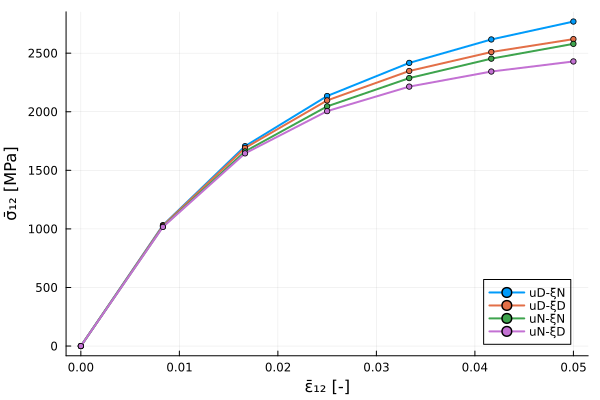

In [16]:
function plot_stress_strain(results, foreground_color)
    plt = Plots.plot(;
        xlabel = "ε̄₁₂ [-]", ylabel = "σ̄₁₂ [MPa]", legend = :bottomright,
        background_color = :transparent, foreground_color,
    )
    for (i, (ubc, ξbc)) in enumerate(cases), format in formats
        r = results[(format, ubc, ξbc)]
        Plots.plot!(
            plt, [0.0; [ε[1, 2] for ε in r.ε̄]], [0.0; [σ[1, 2] for σ in r.σ̄]];
            label = format === :dual ? label(ubc, ξbc) : string(label(ubc, ξbc), " (primal)"), lw = 2, color = i,
            ls = format === :dual ? :solid : :dash, marker = format === :dual ? :circle : :none, ms = 3,
        )
    end
    return plt
end
plot_stress_strain(results, :black)

![](gradient_crystal_plasticity_stress-light.svg)
![](gradient_crystal_plasticity_stress-dark.svg)

*Figure 2*:
Macroscopic shear stress versus shear strain for the 50-grain SVE.

As in Figure 7 of [Carlsson2019](@cite), the two bounding cases $u$D-$\xi$N and
$u$N-$\xi$D also bound the macroscopic stress ($\bar{\sigma}_{12} = 2937$ and
$2671\,\mathrm{MPa}$ at the end), with the $u$D-$\xi$D and $u$N-$\xi$N cases in
between.

For the documentation the plot is saved in a light and a dark variant (matching the
theme) from the full run:

In [17]:
function save_stress_plots(results, dir = ".")
    Plots.savefig(plot_stress_strain(results, :black), joinpath(dir, "gradient_crystal_plasticity_stress-light.svg"))
    Plots.savefig(plot_stress_strain(results, "#d6d6d6"), joinpath(dir, "gradient_crystal_plasticity_stress-dark.svg"))
    return
end
FULL && save_stress_plots(results)

false

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*